#미션2
1. 어떤 조건에서 예약 취소가 빈번하게 발생하는지
2. 예약 취소와 관련이 있는 요소들이 무엇인지 파악하기
3. 어떻게 하면 예약 취소율을 개선할 수 있을지

### 분석에 사용한 주요 컬럼 설명
`is_canceled` 예약 취소는 1  
`children` 예약된 어린이의 수  
`babies` 예약된 아기의 수    
`previous_cancellations` 현재 예약 이전에 고객이 취소한 이전 예약 수  
`previous_bookings_not_canceled` 현재 예약 이전에 고객이 취소하지 않은 이전 예약 수  
`days_in_waiting_list`	예약이 확정되기 전까지 해당 예약이 예약 대기자 명단에 있었던 일수  
`required_car_parking_spaces`	고객이 요구하는 주차 공간 수  
`reservation_status`	예약의 마지막 상태, 총 3가지 카테고리로 구성  
- Canceled: 고객이 예약을 취소함  
- Check-Out: 고객이 체크인을 하고 체크아웃을 함  
- No-Show: 노쇼. 고객이 체크인을 하지 않았고 해당 이유를 알 수 없음.   

## 가설
1. 현재 예약 이전에 취소를 한 고객은 취소율이 높을 것이다.
2. 예약 대기자 명단 대기 일수가 높으면 취소율이 높을 것이다.
3. 주차 공간을 요구하면 취소율이 낮을 것이다.
4. 어린이, 아기가 있는 집은 취소율이 높을 것이다.

In [1]:
# 드라이브 마운트

from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/코드잇/스프린트 미션')

Mounted at /content/drive


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 66.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [4]:
# 데이터 불러오기
hotel_df = pd.read_csv("data/hotel_data_modified.csv")
hotel_df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,A,A,0,394.0,NaN,0,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,E,E,0,9.0,NaN,0,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,D,D,0,9.0,NaN,0,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,A,A,0,89.0,NaN,0,0,0,Check-Out,2017-09-07


In [5]:
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
# 결측치 확인
hotel_df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


내가 세운 모든 가설에서 결측치가 있는 컬럼이 쓰이지 않으므로 결측치 처리는 제외함.

### 가설1 검증

In [7]:
# reservation_status 확인
hotel_df["reservation_status"].value_counts()

,count
reservation_status,
Check-Out,75166
Canceled,43017
No-Show,1207


In [8]:
# is_canceled 확인
hotel_df["is_canceled"].value_counts()

,count
is_canceled,
0,75166
1,44224


reservation_status 컬럼에서의 canceled, no show의 합계와 is_canceled 컬럼에서 취소로 표시된 합계가 동일하므로 reservation_status 컬럼에서의 canceled, no show를 포함한 취소 여부 컬럼은 별도로 생성하지 않고 is_canceled 컬럼을 사용하겠다.

In [9]:
# 가설1 검증을 위한 데이터프레임
hypothesis_1 = hotel_df[["is_canceled", "previous_cancellations", "previous_bookings_not_canceled", "hotel"]]
hypothesis_1

,is_canceled,previous_cancellations,previous_bookings_not_canceled,hotel
0,0,0,0,Resort Hotel
1,0,0,0,Resort Hotel
2,0,0,0,Resort Hotel
3,0,0,0,Resort Hotel
4,0,0,0,Resort Hotel
...,...,...,...,...
119385,0,0,0,City Hotel
119386,0,0,0,City Hotel
119387,0,0,0,City Hotel
119388,0,0,0,City Hotel


In [10]:
# previous_cancellations 확인
hypothesis_1["previous_cancellations"].value_counts()

,count
previous_cancellations,
0,112906
1,6051
2,116
3,65
24,48
11,35
4,31
26,26
25,25


previous_cancellations 컬럼의 분포를 확인한 결과 3회 이상인 고객의 표본 수가 매우 적으므로 0회, 1회, 2회 취소 고객을 대상으로 분석 진행.

In [11]:
# 0회, 1회, 2회 취소 고객만 남기기
hypothesis_1 = hypothesis_1[hypothesis_1["previous_cancellations"] <= 2]

In [12]:
hypothesis_1["previous_cancellations"].value_counts()

,count
previous_cancellations,
0,112906
1,6051
2,116


In [13]:
hypothesis_1.groupby("previous_cancellations")["is_canceled"].agg(cancel_rate = "mean", total_count = "count", cancel_count = "sum")

,cancel_rate,total_count,cancel_count
previous_cancellations,,,
0,0.339061,112906,38282
1,0.944307,6051,5714
2,0.327586,116,38


#### 결과
이전 취소 이력이 없는 고객의 취소율은 33.91%, 이전에 1회 예약을 취소한 고객의 취소율은 94.43%로 매우 높게 나타났다.  
이는 과거 취소 경험이 있는 고객이 현재 예약도 취소할 가능성이 높음을 보여준다.  

다만 이전 취소 횟수가 2회인 고객의 취소율은 32.76%로 나타났는데, 해당 그룹의 표본 수가 116건으로 매우 적어 일반적인 경향으로 해석하기에는 한계가 있다.  

따라서 현재 결과만 봤을 때, 가설1인 이전에 취소를 한 고객은 취소율이 높을 것이다는 성립하지 않는다.  
하지만 이전에 취소한 경험이 있는 고객은 취소율이 높다는 것이 1회 그룹에서 매우 강하게 나타난다.  
그래서 가설1을 수정하면 이전 취소 경험이 있는 고객은 없는 고객보다 현재 예약을 취소할 가능성이 높다고 볼 수 있다.

### 가설2 검증

In [14]:
# 가설2 검증을 위한 데이터프레임
hypothesis_2 = hotel_df[["is_canceled", "days_in_waiting_list", "hotel"]]
hypothesis_2

,is_canceled,days_in_waiting_list,hotel
0,0,0,Resort Hotel
1,0,0,Resort Hotel
2,0,0,Resort Hotel
3,0,0,Resort Hotel
4,0,0,Resort Hotel
...,...,...,...
119385,0,0,City Hotel
119386,0,0,City Hotel
119387,0,0,City Hotel
119388,0,0,City Hotel


In [15]:
hypothesis_2["days_in_waiting_list"].value_counts()

,count
days_in_waiting_list,
0,115692
39,227
58,164
44,141
31,127
...,...
81,1
92,1
74,1


In [16]:
hypothesis_2["days_in_waiting_list"].describe()

,days_in_waiting_list
count,119390.000000
mean,2.321149
std,17.594721
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,391.000000


전체 예약의 75% 이상이 대기일수 0일이다.  
따라서 장기 대기 고객의 표본이 적어 대기를 경험한 고객과 경험하지 않은 고객으로 나눠서 보는 것이 나아 보인다.

In [17]:
# 대기가 없었던 그룹
hypothesis_2_no_waiting = hypothesis_2[hypothesis_2["days_in_waiting_list"] == 0]

In [18]:
# 대기가 없었던 그룹에서 취소율 구하기
hypothesis_2_no_waiting["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.361866
total_count,115692.000000
cancel_count,41865.000000


In [19]:
# 대기가 있던 그룹
hypothesis_2_waiting = hypothesis_2[hypothesis_2["days_in_waiting_list"] > 0]

In [20]:
# 대기가 있던 그룹에서 취소율 구하기
hypothesis_2_waiting["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.637912
total_count,3698.000000
cancel_count,2359.000000


In [21]:
# 취소율 차이
0.637912 / 0.361866

1.7628403884310766

#### 결과
대기 여부에 따른 취소율을 비교하였다.   
분석 결과 대기자 명단에 오르지 않은 고객의 취소율은 36.19%였으며, 대기자 명단에 오른 고객의 취소율은 63.79%로 나타났다.  
이는 예약 확정까지 대기 시간이 발생할 경우 고객이 다른 숙소를 선택하거나 예약 의사를 변경할 가능성이 높아짐을 보여준다.  
따라서 가설2는 채택되었다.  

### 가설3 검증

In [22]:
# 가설3 검증을 위한 데이터프레임
hypothesis_3 = hotel_df[["is_canceled", "required_car_parking_spaces", "hotel"]]
hypothesis_3

,is_canceled,required_car_parking_spaces,hotel
0,0,0,Resort Hotel
1,0,0,Resort Hotel
2,0,0,Resort Hotel
3,0,0,Resort Hotel
4,0,0,Resort Hotel
...,...,...,...
119385,0,0,City Hotel
119386,0,0,City Hotel
119387,0,0,City Hotel
119388,0,0,City Hotel


In [23]:
hypothesis_3["required_car_parking_spaces"].value_counts()

,count
required_car_parking_spaces,
0,111974
1,7383
2,28
3,3
8,2


2대 이상의 주차 공간을 요구한 고객의 표본이 매우 적어, 주차 공간을 요구한 고객과 요구하지 않은 고객으로 나눠 분석한다.

In [24]:
# 주차 요구가 없는 그룹
hypothesis_3_no_parking = hypothesis_3[hypothesis_3["required_car_parking_spaces"] == 0]
hypothesis_3_no_parking

,is_canceled,required_car_parking_spaces,hotel
0,0,0,Resort Hotel
1,0,0,Resort Hotel
2,0,0,Resort Hotel
3,0,0,Resort Hotel
4,0,0,Resort Hotel
...,...,...,...
119385,0,0,City Hotel
119386,0,0,City Hotel
119387,0,0,City Hotel
119388,0,0,City Hotel


In [25]:
hypothesis_3_no_parking["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.394949
total_count,111974.000000
cancel_count,44224.000000


In [26]:
# 주차 요구가 있는 그룹
hypothesis_3_parking = hypothesis_3[hypothesis_3["required_car_parking_spaces"] > 0]
hypothesis_3_parking

,is_canceled,required_car_parking_spaces,hotel
25,0,1,Resort Hotel
29,0,1,Resort Hotel
53,0,1,Resort Hotel
54,0,1,Resort Hotel
55,0,1,Resort Hotel
...,...,...,...
119158,0,1,City Hotel
119198,0,1,City Hotel
119236,0,1,City Hotel
119281,0,1,City Hotel


In [27]:
hypothesis_3_parking["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.0
total_count,7416.0
cancel_count,0.0


주차 공간을 요구한 고객 그룹의 취소율을 계산한 결과 취소율이 0%로 나타났다.   
일반적으로 수천 건의 데이터에서 취소율이 0%로 나타나는 것은 매우 드문 결과이므로, 결과의 신뢰성을 확인하기 위해 추가 검증이 필요하다.
1. is_canceled 컬럼의 분포를 확인하여 취소 데이터가 정상적으로 존재하는지 검증
2. required_car_parking_spaces 별 예약 수, 취소 수, 취소율을 재집계하여 주차 공간 요청 여부에 따른 취소 현황 확인

In [28]:
hypothesis_3_parking["is_canceled"].value_counts()

,count
is_canceled,
0,7416


In [29]:
hypothesis_3["is_canceled"].value_counts()

,count
is_canceled,
0,75166
1,44224


In [30]:
hotel_df.groupby("required_car_parking_spaces")["is_canceled"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
required_car_parking_spaces,,,
0,111974,44224,0.394949
1,7383,0,0.000000
2,28,0,0.000000
3,3,0,0.000000
8,2,0,0.000000


#### 결과
주차 공간을 1개 이상 요청한 모든 그룹에서 취소 건수가 0건으로 확인된다.  
따라서 취소율 0%는 계산 과정의 오류가 아닌 데이터셋의 실제 특성이었다.  
  
주차 공간 요청 여부에 따른 취소율을 분석한 결과, 주차 공간을 요청하지 않은 고객의 취소율은 39.49%, 주차 공간을 요청한 고객의 취소율은 0%이다.  
이는 차량을 이용하는 고객이 상대적으로 여행 계획이 확정되어 있어, 예약 이행 의지가 높은 고객일 가능성을 보여준다.  
따라서 가설은 채택되었다.  

### 가설4 검증

In [31]:
# 가설4 검증을 위한 데이터프레임
hypothesis_4 = hotel_df[["is_canceled", "children", "babies", "hotel"]]
hypothesis_4

,is_canceled,children,babies,hotel
0,0,0.0,0,Resort Hotel
1,0,0.0,0,Resort Hotel
2,0,0.0,0,Resort Hotel
3,0,0.0,0,Resort Hotel
4,0,0.0,0,Resort Hotel
...,...,...,...,...
119385,0,0.0,0,City Hotel
119386,0,0.0,0,City Hotel
119387,0,0.0,0,City Hotel
119388,0,0.0,0,City Hotel


In [32]:
hypothesis_4[["children", "babies"]].value_counts()

,,count
children,babies,
0.0,0,110054
1.0,0,4718
2.0,0,3620
0.0,1,728
1.0,1,140
3.0,0,76
2.0,1,32
0.0,2,12
1.0,2,3


In [33]:
# 자녀가 없는 집
hypothesis_4_adult = hypothesis_4[(hypothesis_4["children"] == 0) & (hypothesis_4["babies"] == 0)]
hypothesis_4_adult

,is_canceled,children,babies,hotel
0,0,0.0,0,Resort Hotel
1,0,0.0,0,Resort Hotel
2,0,0.0,0,Resort Hotel
3,0,0.0,0,Resort Hotel
4,0,0.0,0,Resort Hotel
...,...,...,...,...
119385,0,0.0,0,City Hotel
119386,0,0.0,0,City Hotel
119387,0,0.0,0,City Hotel
119388,0,0.0,0,City Hotel


In [34]:
hypothesis_4_adult["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.37219
total_count,110054.00000
cancel_count,40961.00000


In [35]:
# 자녀가 있는 집
hypothesis_4_kids = hypothesis_4[(hypothesis_4["children"] > 0) | (hypothesis_4["babies"] > 0)]
hypothesis_4_kids

,is_canceled,children,babies,hotel
13,0,1.0,0,Resort Hotel
45,1,2.0,0,Resort Hotel
55,0,2.0,0,Resort Hotel
65,0,2.0,0,Resort Hotel
87,1,1.0,0,Resort Hotel
...,...,...,...,...
119270,0,1.0,0,City Hotel
119287,0,1.0,0,City Hotel
119293,0,2.0,0,City Hotel
119318,0,1.0,0,City Hotel


In [36]:
hypothesis_4_kids["is_canceled"].agg(
    cancel_rate="mean",
    total_count="count",
    cancel_count="sum"
)

,is_canceled
cancel_rate,0.349228
total_count,9332.000000
cancel_count,3259.000000


#### 결과
자녀를 동반하지 않은 고객의 취소율은 37.22%, 자녀를 동반한 고객의 취소율은 34.92%로 나타났다.  
자녀를 동반한 고객의 취소율이 소폭 낮게 나타났으나, 두 그룹 간 차이는 2.30%p에 불과했다.  
따라서 자녀 동반 여부는 예약 취소에 큰 영향을 미치는 요인으로 보기 어렵다고 판단한다.  


## 결론

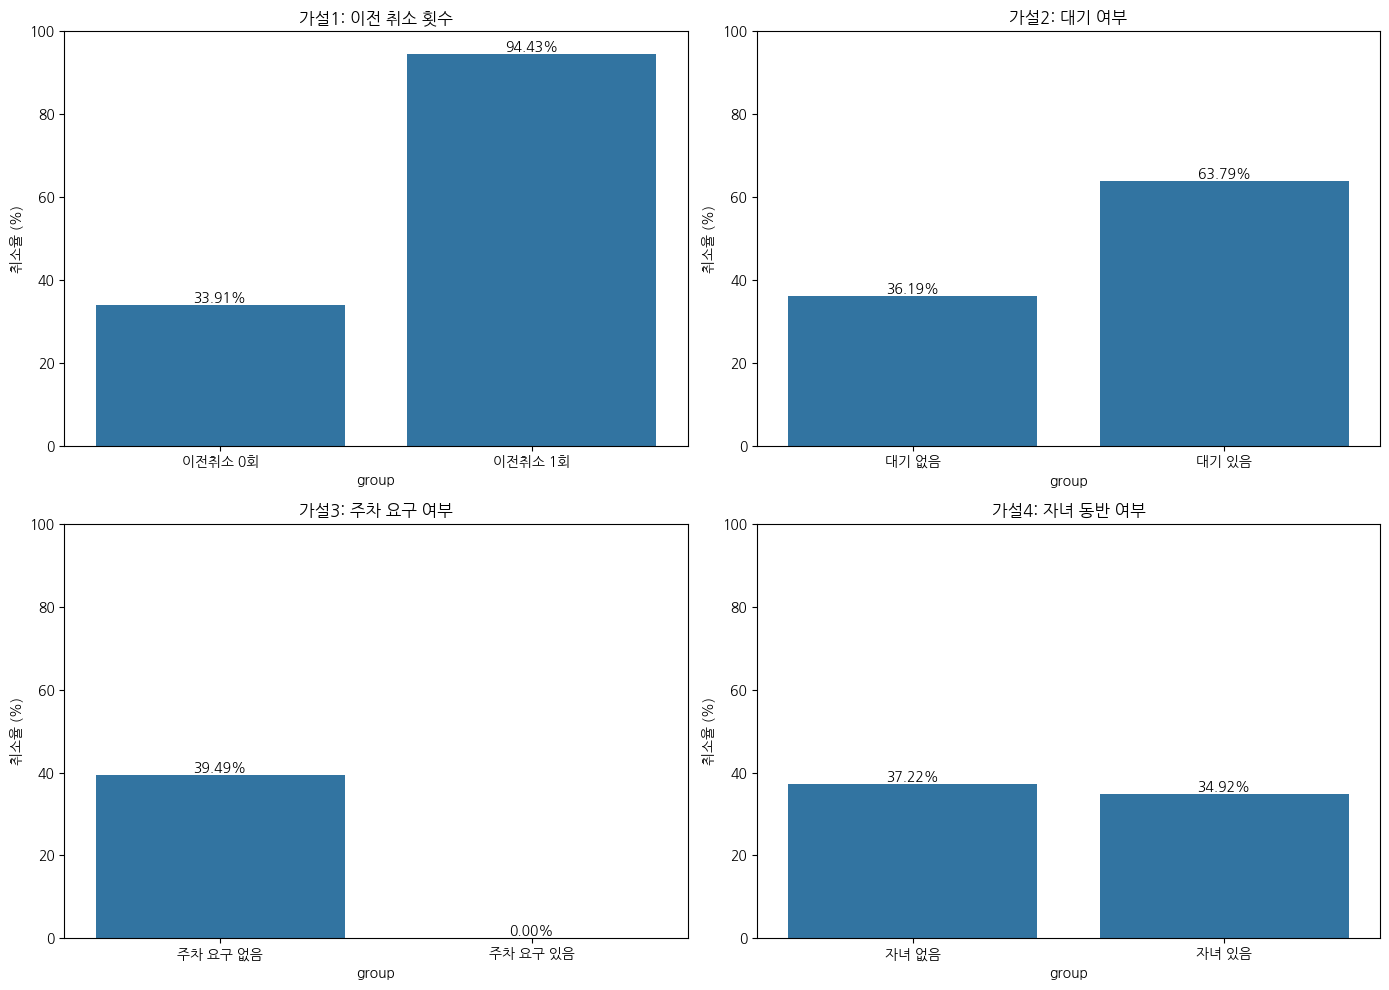

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 가설1
sns.barplot(
    data=cancel_rate_df[cancel_rate_df["hypothesis"] == "가설1"],
    x="group",
    y="cancel_rate",
    ax=axes[0, 0]
)
axes[0, 0].set_title("가설1: 이전 취소 횟수")
axes[0, 0].set_ylabel("취소율 (%)")

# 가설2
sns.barplot(
    data=cancel_rate_df[cancel_rate_df["hypothesis"] == "가설2"],
    x="group",
    y="cancel_rate",
    ax=axes[0, 1]
)
axes[0, 1].set_title("가설2: 대기 여부")
axes[0, 1].set_ylabel("취소율 (%)")

# 가설3
sns.barplot(
    data=cancel_rate_df[cancel_rate_df["hypothesis"] == "가설3"],
    x="group",
    y="cancel_rate",
    ax=axes[1, 0]
)
axes[1, 0].set_title("가설3: 주차 요구 여부")
axes[1, 0].set_ylabel("취소율 (%)")

# 가설4
sns.barplot(
    data=cancel_rate_df[cancel_rate_df["hypothesis"] == "가설4"],
    x="group",
    y="cancel_rate",
    ax=axes[1, 1]
)
axes[1, 1].set_title("가설4: 자녀 동반 여부")
axes[1, 1].set_ylabel("취소율 (%)")

# 막대 위 수치 표시
for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%")
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

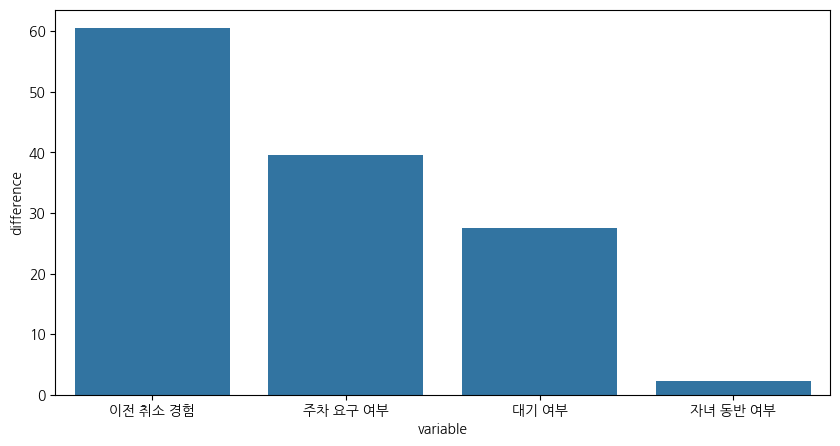

In [38]:
# 변수별 영향력 비교 그래프
impact_df = pd.DataFrame({
    "variable": [
        "이전 취소 경험",
        "주차 요구 여부",
        "대기 여부",
        "자녀 동반 여부"
    ],
    "difference": [
        60.52,
        39.49,
        27.60,
        2.30
    ]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=impact_df, x="variable", y="difference")
plt.show()

이전 예약 취소 경험이 있는 고객과 예약 대기자 명단에 등록된 고객에게서 예약 취소가 빈번하게 발생하였다.    

| 변수 | 결과 | 영향도 |
|------|------|--------|
| previous_cancellations | 채택 | 높음 |
| days_in_waiting_list | 채택 | 높음 |
| required_car_parking_spaces | 채택 | 높음 |
| children, babies | 채택 | 높음 |

다음 표에서 알 수 있듯이, 예약 취소와 관련 있는 변수는 previous_cancellations, days_in_waiting_list, required_car_parking_spaces이 있었다.  

개선 방안
1. 예약금 제도를 운영하여 취소를 방지할 수 있다.
2. 대기 확정까지의 프로세스를 단축한다.
3. 대기 고객 대상으로 실시간 상태 안내를 한다.
4. 호텔 셔틀 버스를 운영한다.
5. 택시 할인 쿠폰을 도입한다.